# Training

Training done in google colab, by loading on the drive the datasets (SPRITES, HMNIST), or by uploading it (Physionet).

In [ ]:
from google.colab import userdata
import os
# classic token on github - set up in secrets
token = userdata.get('GITHUB_TOKEN')
branch_name = 'gpvae-integration'
# Clone your private repo
os.system(f'git clone -b {branch_name} https://{token}@github.com/sebik2001/ImputeGAP-GP-VAE')

0

In [ ]:
%cd ImputeGAP-GP-VAE

/content/ImputeGAP-GP-VAE


In [ ]:
# load content of google drive (SPRITES file size is too large to be uploaded)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# dataset_folder = 'datasets/physionet'
# file_name = 'x_miss_nan.txt'
# text_file = True
# config_file = "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_physionet.yaml"

# dataset_folder = 'datasets/hmnist'
# dataset_folder = '/content/drive/MyDrive/gpvae/hmnist'
# file_name = 'x_miss_nan.npy'
# text_file = False
# config_file = "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_hmnist.yaml"

# dataset_folder = 'datasets/sprites'
dataset_folder = '/content/drive/MyDrive/gpvae/sprites'
file_name = 'x_miss_nan.npy'
text_file = False
config_file = "imputegap/wrapper/AlgoPython/GPVAE/config_gpvae_sprites.yaml"

if not os.path.exists(dataset_folder): os.makedirs(dataset_folder)
dataset_path = os.path.join(dataset_folder, file_name)

In [ ]:
from imputegap.recovery.manager import TimeSeries
from imputegap.algorithms.gp_vae import gp_vae
import numpy as np

# initialize the time series object
ts = TimeSeries()

# load the dataset
if text_file:
  ts.load_series(dataset_path)
else:
  npy_file = np.load(dataset_path)
  ts.import_matrix(npy_file)

ts_m_imputed = gp_vae(ts.data,
                      config_file,
                      verbose=False)

2026-01-12 13:34:26.711007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-12 13:34:26.737376: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-12 13:34:26.737408: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-12 13:34:26.753355: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-12 13:34:27.776871: W tensorflow/compiler/tf


(SYS) The dataset is loaded from ../external/datasets/physionet/merged/x_miss_nan.txt



2026-01-12 13:34:41.602856: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-12 13:34:41.639079: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-12 13:34:41.641256: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Instructions for updating:
`MultivariateNormalFullCovariance` is deprecated, use `MultivariateNormalTriL(loc=loc, scale_tril=tf.linalg.cholesky(covariance_matrix))` instead.


2026-01-12 13:34:42.290202: I tensorflow/core/util/cuda_solvers.cc:178] Creating GpuSolver handles for stream 0x6535bafcffd0
2026-01-12 13:34:42.935128: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


...

Validation loss = 21534.861 | NLL = 349.328 | KL = 105927.641



Training progress:  37%|███▋      | 930/2498 [06:21<07:35,  3.44it/s]  

Learning rate: 0.0005000000237487257 | Global gradient norm: 164.60
Step 930) Time = 17.527623
Train loss = 21518.877 | NLL = 340.870 | KL = 105890.031


2026-01-12 13:41:18.610279: W external/local_tsl/tsl/framework/bfc_allocator.cc:487] Allocator (GPU_0_bfc) ran out of memory trying to allocate 19.69MiB (rounded to 20643840)requested by op BatchMatMulV2
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-01-12 13:41:18.610379: I external/local_tsl/tsl/framework/bfc_allocator.cc:1044] BFCAllocator dump for GPU_0_bfc
2026-01-12 13:41:18.610406: I external/local_tsl/tsl/framework/bfc_allocator.cc:1051] Bin (256): 	Total Chunks: 188, Chunks in use: 186. 47.0KiB allocated for chunks. 46.5KiB in use in bin. 2.1KiB client-requested in use in bin.
2026-01-12 13:41:18.610424: I external/local_tsl/tsl/framework/bfc_allocator.cc:1051] Bin (512): 	Total Chunks: 13, Chunks in use: 12. 7.0KiB allocated for chunks. 6.2KiB in use in bin. 5.6KiB client-requested in use in bin.
2026-01-12 13:41:1

ResourceExhaustedError: {{function_node __wrapped__BatchMatMulV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[64,35,48,48] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:BatchMatMulV2] name: 

In [ ]:
# Create a file zip of the folder containing training results
# From Colab is then possible to download the zip file
folder_name = "20260107_164259"
!zip -r model.zip "/content/ImputeGAP-GP-VAE/imputegap_assets/models/{folder_name}"

  adding: imputegap_assets/models/20260107_164259/ (stored 0%)
  adding: imputegap_assets/models/20260107_164259/ckpt-4.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-19.data-00000-of-00001 (deflated 7%)
  adding: imputegap_assets/models/20260107_164259/ckpt-11.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-3.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-15.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-9.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-12.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-20.data-00000-of-00001 (deflated 7%)
  adding: imputegap_assets/models/20260107_164259/ckpt-12.data-00000-of-00001 (deflated 7%)
  adding: imputegap_assets/models/20260107_164259/ckpt-7.index (deflated 68%)
  adding: imputegap_assets/models/20260107_164259/ckpt-1.index (deflated 68%)
  adding: imputegap_assets/models/

# Training results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_training_results

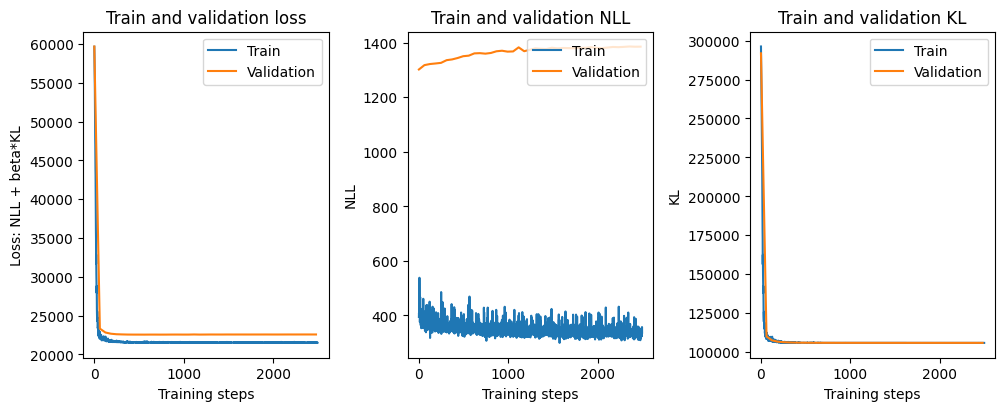

In [2]:
exp_folder = '/home/kaeslin/Downloads/physionet_trained'
plot_training_results(exp_folder)

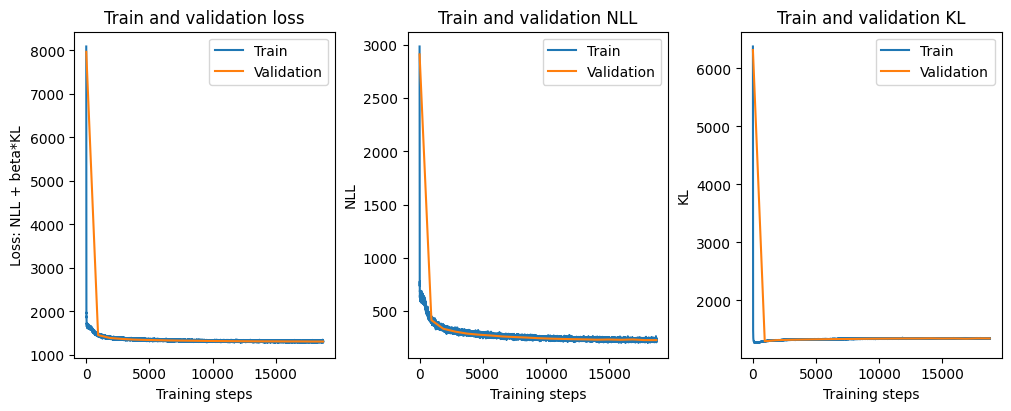

In [3]:
exp_folder = '/home/kaeslin/Downloads/hmnist_trained'
plot_training_results(exp_folder)

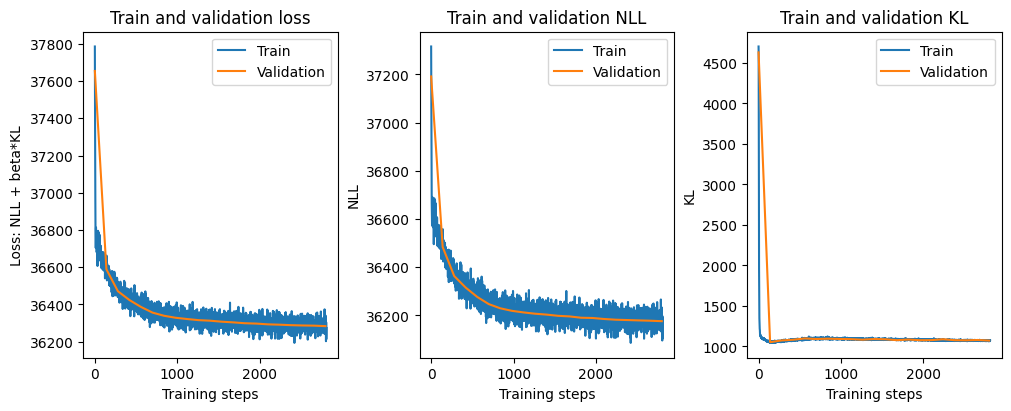

In [4]:
exp_folder = '/home/kaeslin/Downloads/sprites_trained'
plot_training_results(exp_folder)